- Name: Tejas Pandya (tbp8777)
- Homework 1

In [98]:
# Importing required libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.tsa.stattools import adfuller
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

# UCI API for wine dataset download
import sys; sys.path.insert(0, "../src")
# local copies in data/uci/; falls back to the UCI API only if one is missing
from mlscratch.datasets import load_uci as fetch_ucirepo 

#### 1. Data Exploration & Preprocessing

##### Q. Load the provided quarterly GDP dataset (1947-2023)

In [80]:
# reading the FRED GDP series committed in data/ (https://fred.stlouisfed.org/series/GDP)
gdp_dataset = pd.read_csv("../data/GDP_data.csv")  # FRED GDP, vintage of 2026-10-02 (saved outputs below used an earlier vintage)

# creating new column date with datetime format as observation_date contained dates in string format
gdp_dataset['Date'] = pd.to_datetime(gdp_dataset['observation_date'])

# dropping the unnecessary observation_date column
gdp_dataset = gdp_dataset.drop('observation_date', axis=1)

# setting Date column as index and sorting it
gdp_dataset = gdp_dataset.set_index('Date').sort_index()
gdp_dataset.head()

,GDP
Date,
1947-01-01,243.164
1947-04-01,245.968
1947-07-01,249.585
1947-10-01,259.745
1948-01-01,265.742


##### Q. Create time series plots of the data

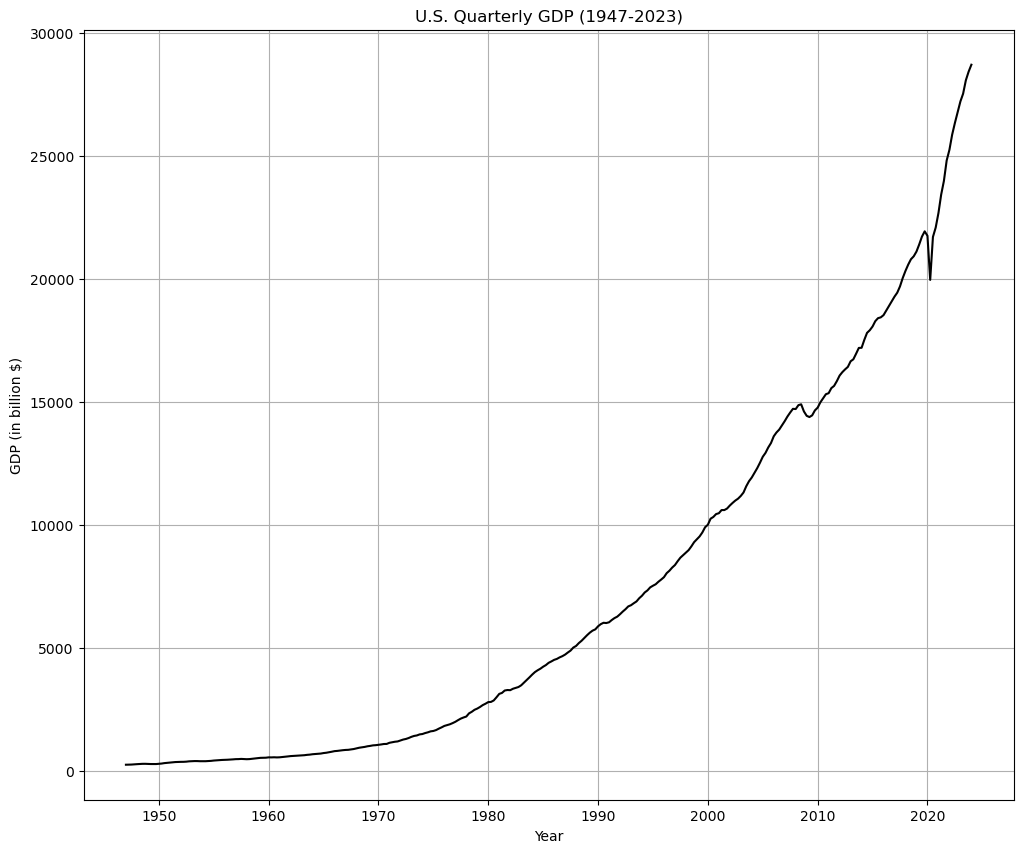

In [82]:
plt.figure(figsize=(12,10)) # setting plot size

# plotting GDP dataset as a line graph with Date (index) on X-axis and GDP data on Y-axis
plt.plot(gdp_dataset.index,gdp_dataset['GDP'], color = 'black') 

# setting axis labels and title of the graph
plt.title("U.S. Quarterly GDP (1947-2023)")
plt.xlabel("Year")
plt.ylabel("GDP (in billion $)")

# turning plot grid lines on
plt.grid(True)

plt.show()

#### 2. Model Determination

##### Q. Decompose the series into trend, seasonal, and residual components. Justify whether you will be using an additive or multiplicative decomposition.

**Justification:** 
U.S. GDP data is exponentially growing over the entire time span (1947-2023). Also, the absolute magnitude of seasonal volatility increases proportionally with the overall growth of the GDP trend. Because of these reasons, I am choosing to use multiplicative model: 
$$Y_t = Trend_t \times Seasonal_t \times Residual_t$$

**Calculating the Trend ($T_t$):**
Because quarterly data has an even period ($m=4$), we cannot use a simple moving average because it would not align symmetrically with time $t$. Instead, we use a Centered Moving Average (CMA). The formula for the CMA at time $t$ is:

$$T_t = \frac{1}{4} \left( \frac{1}{2}Y_{t-2} + Y_{t-1} + Y_t + Y_{t+1} + \frac{1}{2}Y_{t+2} \right)$$

**Detrending the Series:**
To isolate the seasonal and residual effects, we divide the original data by our calculated trend:

$$D_t = \frac{Y_t}{T_t} = S_t \times R_t$$

**Calculating the Seasonal Component ($S_t$):**
First, we find the unnormalized seasonal index $S'_k$ for each specific quarter $k$ (where $k \in \{1, 2, 3, 4\}$) by taking the average of all detrended values corresponding to that quarter:

$$S'_k = \frac{1}{N_k} \sum_{j=1}^{N_k} D_{k + 4(j-1)}$$

Where $N_k$ is the total number of times quarter $k$ appears in the dataset. 

Next, we normalize these indices so that their average is exactly 1. The final normalized seasonal component for quarter $k$ is:

$$S_k = S'_k \times \frac{4}{\sum_{i=1}^{4} S'_i}$$

**Calculating the Residual Component ($R_t$):**
Finally, we isolate the random noise (residuals) by dividing the original data by both the trend and the seasonal components:

$$R_t = \frac{Y_t}{T_t \times S_t}$$

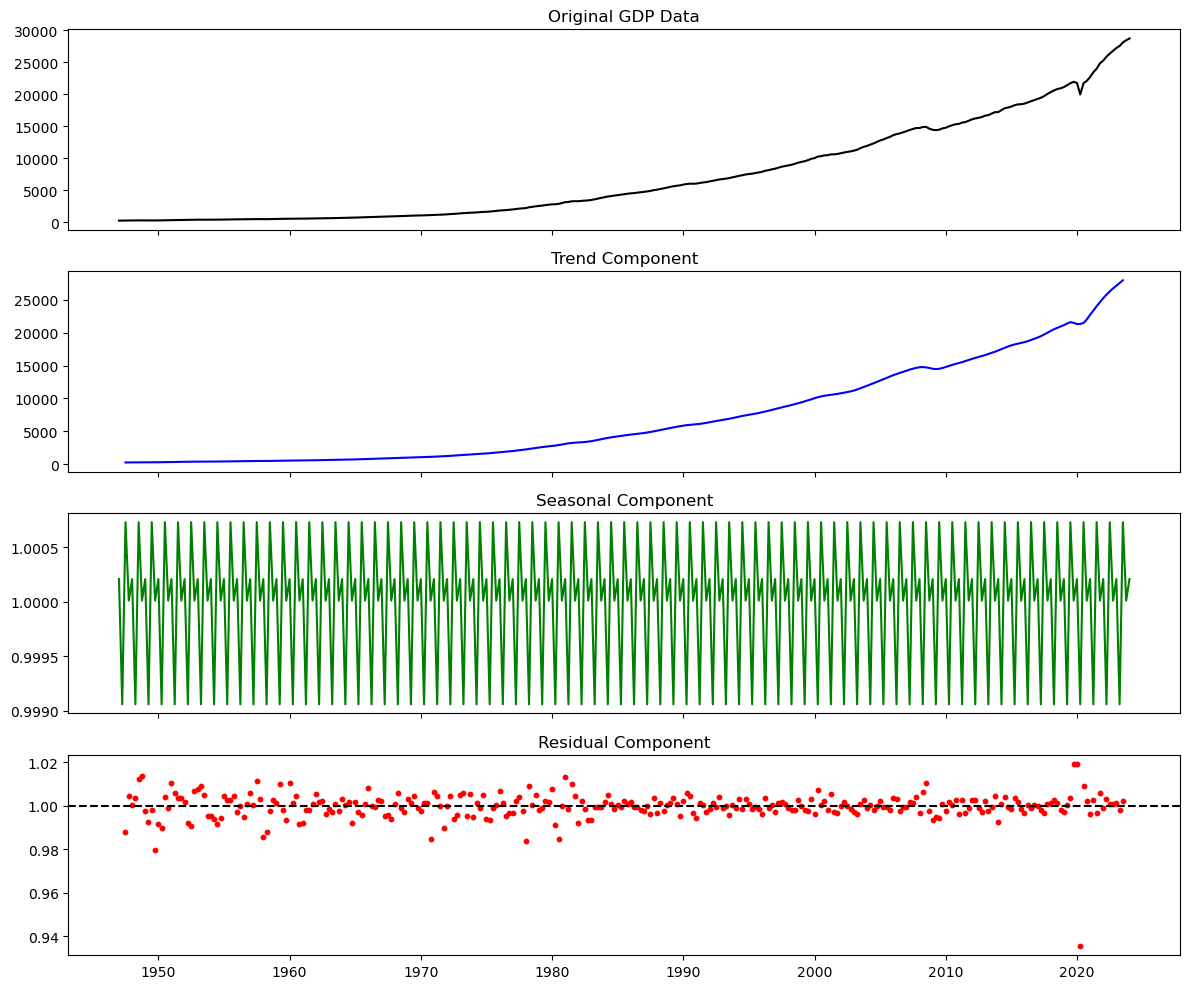

In [ ]:
def decompose_multiplicative(series_values, period=4):
    n = len(series_values)
    trend = np.full(n, np.nan)
    
    # Calculate Trend Component (Centered Moving Average for s=4)
    # Weights: [0.5, 1, 1, 1, 0.5] / 4
    for i in range(2, n - 2):
        trend[i] = (0.5*series_values[i-2] + 
                    1.0*series_values[i-1] + 
                    1.0*series_values[i] + 
                    1.0*series_values[i+1] + 
                    0.5*series_values[i+2]) / period
        
    # Isolating Seasonality + Residuals (Multiplicative: Data / Trend)
    detrended = series_values / trend
    
    # Calculating Seasonal Component
    seasonal_indices = np.zeros(period)
    for i in range(period):
        # Extract all available values for this specific quarter (ignoring NaNs)
        quarter_vals = detrended[i::period]
        seasonal_indices[i] = np.nanmean(quarter_vals)
        
    # Normalizing seasonal indices so their average is exactly 1.0
    seasonal_indices = seasonal_indices / np.mean(seasonal_indices)
    
    # Mapping the 4 seasonal indices across the entire length of the dataset
    seasonal = np.array([seasonal_indices[i % period] for i in range(n)])
    
    # Calculating Residual Component (Multiplicative: Data / (Trend * Seasonal))
    residual = series_values / (trend * seasonal)
    
    return trend, seasonal, residual

y = gdp_dataset['GDP'].values
trend_comp, seasonal_comp, residual_comp = decompose_multiplicative(y, period=4)

# setting up plots for all multiplicative decomposition components
fig, axes = plt.subplots(4, 1, figsize=(12, 10), sharex=True)

axes[0].plot(gdp_dataset.index, y, color='black')
axes[0].set_title('Original GDP Data')

axes[1].plot(gdp_dataset.index, trend_comp, color='blue')
axes[1].set_title('Trend Component')

axes[2].plot(gdp_dataset.index, seasonal_comp, color='green')
axes[2].set_title('Seasonal Component')

axes[3].scatter(gdp_dataset.index, residual_comp, color='red', s=10)
axes[3].axhline(1, color='black', linestyle='--')
axes[3].set_title('Residual Component')

plt.tight_layout()
plt.show()

In [94]:
# Test for stationarity using the Augmented Dickey-Fuller test using statsmodel
def adf_test(series_name):
    result = adfuller(series_name)
    print(f'ADF Statistic: {result[0]}')
    print(f'p-value: {result[1]}')

    if result[1] <= 0.05:
        print("Result: Stationary (since p-value is <= 0.05)\n")
    else:
        print("Result: Non-Stationary (since p-value is > 0.05)\n")

adf_test(gdp_dataset)

ADF Statistic: 8.86771626286702
p-value: 1.0
Result: Non-Stationary (since p-value is > 0.05)



In [ ]:
# Document any transformations applied to achieve stationarity, and specify the chosen parameter d 

# I will apply transformations one by one and check for stationarity using ADF after each step
# Log Transform to convert GDP's absolute growth into percentage growth
gdp_log = np.log(gdp_dataset)

# checking for stationarity after log transformation
print("ADF Test after log transformation:")
adf_test(gdp_log)

# Now transforming gdp_log using First-order Differencing (d=1)
gdp_diff = gdp_log.diff().dropna()

# checking for stationarity after differencing
print("ADF Test after log and differencing:")
adf_test(gdp_diff)

ADF Test after log transformation:
ADF Statistic: -2.0964973993735154
p-value: 0.24592534536617433
Result: Non-Stationary (since p-value is > 0.05)

ADF Test after log and differencing:
ADF Statistic: -8.62166127130648
p-value: 6.081836933034726e-14
Result: Stationary (since p-value is <= 0.05)



Documentation of parameters:
- log transformation
- differencing (d) = 1
  
I did all these transformations to make the dataset stationary.

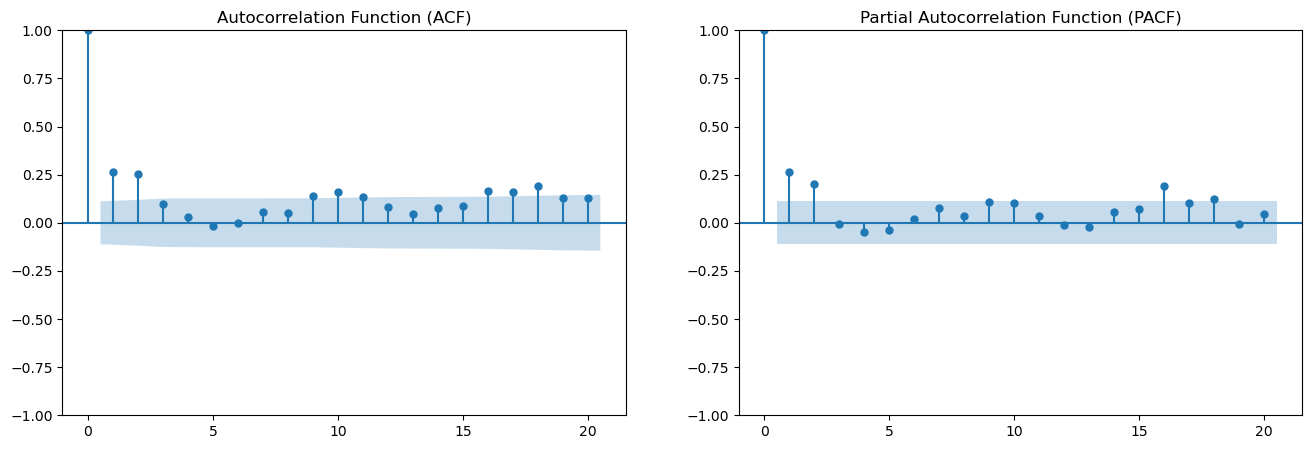

In [ ]:
# Analyze ACF/PACF plots to determine appropriate p, q parameters
# adjacent plots for ACF and PACF
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 5))

# Plotting ACF on the transformed 'gdp_diff' data
# setting lag = 20 (5 years = 20 quarters)
plot_acf(gdp_diff, lags=20, ax=ax1)
ax1.set_title('Autocorrelation Function (ACF)')

# Plotting PACF on the transformed 'gdp_diff' data
# method chosen: OLS
plot_pacf(gdp_diff, lags=20, ax=ax2, method='ols')
ax2.set_title('Partial Autocorrelation Function (PACF)')

plt.show()

- Looking at PACF graph above: p = 2
- Looking at ACF graph above: q = 2

### Q: Identify seasonal components and determine P, D, Q, s parameters if necessary

Seasonal Parameters ($P, D, Q, s$):
- $s = 4$: The seasonal period is 4 because the dataset is U.S. Quarterly GDP, meaning the seasonal cycle repeats every 4 quarters.
- $D = 0$: The seasonal differencing order is 0. Applying a difference ($d=1$) was sufficient to make the data stationary (as proven by the ADF test p-value). An additional seasonal difference is not required.
- $P = 1$: The seasonal autoregressive order is 1. Looking at the PACF plot, there is a visible correlation around the first seasonal lag (Lag 4), indicating that the GDP from exactly one year ago influences the current quarter.
- $Q = 0$: The seasonal moving average order is 0. There are no strong, isolated spikes at the seasonal lags in the ACF plot that would necessitate a seasonal moving average term.


### Q: Justify your choice of the linear model you are using and its parameters with clear explanations of your reasoning

I have chosen AR(4) linear model on the log-differenced, stationary GDP data. It is highly appropriate because it uses exactly one year of historical quarterly data (Lags 1 through 4) to predict the next quarter, successfully capturing both recent trend momentum and the seasonal quarterly cycle.

# Model Training & Evaluation

In [105]:
# Q. Split the data into training (80%) and test (20%) sets. Make sure to avoid the look-ahead bias
split_index = int(len(gdp_diff) * 0.8)
train_data = gdp_diff.iloc[:split_index].values.flatten()
test_data = gdp_diff.iloc[split_index:].values.flatten()

# function to create lagged feature matrix
def feature_lag_matrix(time_series, p):
    X, y = [], []
    for i in range(len(time_series) - p):
        X.append(time_series[i : i + p])
        y.append(time_series[i + p])
    return np.array(X), np.array(y)

# Creating train and test data for AR(4) model
p_lags = 4
X_train, y_train = feature_lag_matrix(train_data, p_lags)
X_test, y_test = feature_lag_matrix(test_data, p_lags)


# Q. Train your selected linear model on the training data
# Add a column of ones to X for the intercept term
X_train_b = np.c_[np.ones((len(X_train), 1)), X_train]

# Train using OLS Equation : beta = (X^T * X)^-1 * X^T * y
beta_ar4 = np.linalg.inv(X_train_b.T @ X_train_b) @ X_train_b.T @ y_train


# Q. Generate forecasts for the test period
X_test_b = np.c_[np.ones((len(X_test), 1)), X_test]
predictions_ar4 = X_test_b @ beta_ar4

# Q. Evaluate the model using multiple metrics: RMSE, MAE, MAPE
print(f"RMSE: {np.sqrt(np.mean((y_test - predictions_ar4)**2))}")
print(f"MAE:  {np.mean(np.abs(y_test - predictions_ar4))}")
print(f"MAPE: {np.mean(np.abs((y_test - predictions_ar4) / (y_test)) * 100)}%")

RMSE: 0.020605314556391845
MAE:  0.008965280346139273
MAPE: 153.67298264301462%


### # Q. Provide detailed interpretation of each metric
- RMSE (0.0206): an RMSE of 0.02 indicates that our predictions deviate from the true value by about 0.02 units, penalizing larger forecast errors more heavily.

- MAE (0.0089): This tells us that, on average, our model's forecast is off by an absolute magnitude of just 0.0089 units in the log-differenced space. This is a very low baseline error, showing the model accurately tracks the typical quarterly growth fluctuations.

- MAPE (153.67%): It appears extremely high at ~153.67%. Because the target data was differenced to achieve stationarity, the actual true values are often very close to zero. Dividing by a near-zero actual value artificially inflates the percentage error to massive extremes, making MAPE an unreliable evaluation metric for differenced time series compared to RMSE and MAE.

# 4. Comparative Analysis

In [106]:
# Q. Train a second model (either a different linear model specification or a different type of model)
# For my second model, I am choosing AR(1).
p_lags_2 = 1 # looking at the immediately preceding quarter
X_train_2, y_train_2 = feature_lag_matrix(train_data, p_lags_2)
X_test_2, y_test_2 = feature_lag_matrix(test_data, p_lags_2)

# Add a column of ones to X for the intercept term
X_train_2_b = np.c_[np.ones((len(X_train_2), 1)), X_train_2]

# Train using OLS Equation : beta = (X^T * X)^-1 * X^T * y
beta_ar1 = np.linalg.inv(X_train_2_b.T @ X_train_2_b) @ X_train_2_b.T @ y_train_2

# Generating forecasts for the test period
X_test_2_b = np.c_[np.ones((len(X_test_2), 1)), X_test_2]
predictions_ar1 = X_test_2_b @ beta_ar1

# Evaluating the AR(1) model using multiple metrics: RMSE, MAE, MAPE
print(f"RMSE: {np.sqrt(np.mean((y_test_2 - predictions_ar1)**2))}")
print(f"MAE:  {np.mean(np.abs(y_test_2 - predictions_ar1))}")
print(f"MAPE: {np.mean(np.abs((y_test_2 - predictions_ar1) / y_test_2)) * 100}%")

RMSE: 0.020226000440046632
MAE:  0.008914298090942564
MAPE: 145.7412278521505%


##### Q. Compare performance with your first model

Comparative Analysis: AR(4) vs. AR(1):
- Performance Comparison:the simpler AR(1) model outperformed the more complex AR(4) model across all metrics on the test set. The AR(1) model achieved a lower RMSE (~0.0202 vs ~0.0206) and a lower MAE (~0.00891 vs ~0.00896). This suggests that while the $s=4$ seasonal lag existed in the ACF/PACF plots, including those extra parameters caused the AR(4) model to slightly overfit to the training data's noise, making it less accurate on unseen data.


##### Q. Discuss strengths and weaknesses of each approach
- Model 1: AR(4) Strengths & Weaknesses:
  - Strengths: By including 4 lags, it mathematically attempts to capture the quarterly seasonal cycle ($s=4$) and maps closely to the actual visual fingerprints seen in the PACF plot.
  - Weaknesses: It requires more parameters (degrees of freedom). As evidenced by the higher error metrics on the test set, this increased complexity made the model more susceptible to memorizing historical noise rather than learning the pure underlying economic trend.
- Model 2: AR(1) Strengths & Weaknesses:
  - Strengths: Its strict assumption that the current quarter's growth relies almost entirely on the immediately preceding quarter makes it highly robust to overfitting, which directly resulted in superior forecasting accuracy on the test set.
  - Weaknesses: It is completely "blind" to seasonality. Because it only looks one quarter back, it relies purely on short-term momentum.

# Task 2: Stationarity of Autoregressive Models

### Part 1: Simple Case – First-Order Autoregressive Model AR(1)

**Objective:** Prove that an AR(1) process is stationary if and only if the root of its characteristic polynomial lies outside the unit circle.

**Proof:**
Defining an AR(1) process as below:
$$X_t = \phi X_{t-1} + \epsilon_t$$
where $\epsilon_t$ is a white noise process with mean $0$ and finite variance $\sigma^2$.

Using the lag operator $L$ where $L^k X_t = X_{t-k}$, we can rewrite the above equation as:
$$(1 - \phi L)X_t = \epsilon_t$$

The characteristic polynomial of this process is obtained by replacing the lag operator with a complex variable $z$:
$$\Phi(z) = 1 - \phi z = 0$$

Solving for the root $z$, we get:
$$z = \frac{1}{\phi}$$

To analyze stationarity, we can solve for $X_t$ by recursive substitution (iterating backwards in time):
$$X_t = \epsilon_t + \phi(\phi X_{t-2} + \epsilon_{t-1}) = \dots = \sum_{j=0}^{k} \phi^j \epsilon_{t-j} + \phi^{k+1}X_{t-(k+1)}$$

Taking the limit as $k \to \infty$, $X_t$ can be expressed as an infinite moving average, $\text{MA}(\infty)$, process:
$$X_t = \sum_{j=0}^{\infty} \phi^j \epsilon_{t-j}$$

For $X_t$ to be weakly stationary, it must have a constant, finite mean and a finite, time-invariant variance. 
The expected value is $\mathbb{E}[X_t] = 0$. 
The variance is given by:
$$\text{Var}(X_t) = \text{Var}\left(\sum_{j=0}^{\infty} \phi^j \epsilon_{t-j}\right) = \sigma^2 \sum_{j=0}^{\infty} \phi^{2j}$$

This is an infinite geometric series. For the variance to be finite (and thus for the series to converge in mean square), the common ratio must satisfy:
$$|\phi^2| < 1 \implies |\phi| < 1$$

Relating this back to the root of the characteristic polynomial $z = \frac{1}{\phi}$:
$$|\phi| < 1 \iff \left|\frac{1}{z}\right| < 1 \iff |z| > 1$$

**Conclusion:** If $|z| > 1$, the infinite sum converges, the variance is finite (specifically $\frac{\sigma^2}{1-\phi^2}$), and the autocovariance depends only on the lag, meaning the process is stationary. If $|z| \le 1$, the variance diverges to infinity, meaning the process is non-stationary. Therefore, the AR(1) process is stationary if and only if the root of its characteristic polynomial lies strictly outside the unit circle.

---

### Part 2: General Case – Autoregressive Model of Arbitrary Order AR(p)

**Objective:** Extend the proof to show an AR(p) model is stationary if and only if all roots of its characteristic polynomial lie outside the unit circle.

**Proof:**
Defining an AR(p) process as below:
$$X_t = \phi_1 X_{t-1} + \phi_2 X_{t-2} + \dots + \phi_p X_{t-p} + \epsilon_t$$

Using the lag operator $L$, the above equation can be expressed as:
$$(1 - \phi_1 L - \phi_2 L^2 - \dots - \phi_p L^p)X_t = \epsilon_t$$
$$\Phi(L)X_t = \epsilon_t$$

The corresponding characteristic polynomial is:
$$\Phi(z) = 1 - \phi_1 z - \phi_2 z^2 - \dots - \phi_p z^p = 0$$

For the process $X_t$ to be strictly stationary, it must be representable as a convergent linear combination of current and past white noise terms ($\text{MA}(\infty)$ representation):
$$X_t = \Psi(L)\epsilon_t = \sum_{j=0}^{\infty} \psi_j \epsilon_{t-j}$$

For this series to converge absolutely (ensuring finite variance and strict stationarity), we require:
$$\sum_{j=0}^{\infty} |\psi_j| < \infty$$

We find $\Psi(L)$ by inverting the AR polynomial:
$$\Psi(L) = \Phi^{-1}(L) = \frac{1}{\Phi(L)}$$

We can now factor the characteristic polynomial $\Phi(z)$ in terms of its $p$ complex roots $z_1, z_2, \dots, z_p$:
$$\Phi(z) = \prod_{i=1}^{p} \left(1 - \frac{z}{z_i}\right)$$

Thus, the inverse polynomial $\Psi(z)$ is:
$$\Psi(z) = \frac{1}{\prod_{i=1}^{p} \left(1 - \frac{z}{z_i}\right)}$$

Using partial fraction decomposition, we can expand $\Psi(z)$ as:
$$\Psi(z) = \sum_{i=1}^{p} \frac{c_i}{1 - \frac{z}{z_i}}$$
where $c_i$ are constants.

We can express each term as an infinite geometric series:
$$\frac{1}{1 - \frac{z}{z_i}} = \sum_{j=0}^{\infty} \left(\frac{z}{z_i}\right)^j$$

Therefore, the coefficients $\psi_j$ of the $\text{MA}(\infty)$ expansion are linear combinations of the terms $(1/z_i)^j$. 
For the absolute convergence condition $\sum_{j=0}^{\infty} |\psi_j| < \infty$ to hold, every geometric series in the partial fraction expansion must converge. 

The convergence of $\sum_{j=0}^{\infty} \left(\frac{1}{z_i}\right)^j$ requires the magnitude of the common ratio to be strictly less than $1$:
$$\left|\frac{1}{z_i}\right| < 1 \quad \text{for all } i = 1, 2, \dots, p$$

This mathematically implies:
$$|z_i| > 1 \quad \text{for all } i = 1, 2, \dots, p$$

**Conclusion:**
If all roots $z_i$ of the characteristic polynomial $\Phi(z) = 0$ satisfy $|z_i| > 1$, the $\text{MA}(\infty)$ representation converges, and the AR(p) process is stationary. If any root satisfies $|z_i| \le 1$, the corresponding expansion diverges, making the variance of $X_t$ infinite and the process non-stationary. Thus, an AR(p) model is stationary if and only if all roots of its characteristic polynomial lie strictly outside the unit circle in the complex plane.

# Task 3: Principal Component Analysis Implementation

In [47]:
# loading the wine dataset

# fetch UCI dataset using its API
wine_quality = fetch_ucirepo(id=186) 
  
# loading data as pandas dataframes separating features and target variable (quality)
wine_features = wine_quality.data.features 
wine_quality_score = wine_quality.data.targets

# converting above data into numpy arrays for faster calculations
wine_features = wine_features.to_numpy()
wine_quality_score = wine_quality_score.to_numpy()

### 1.  Implementation
-  Code a complete PCA algorithm without using existing PCA libraries 
-  Your implementation must include: 
    -  Data centering/standardization
    -  Covariance matrix computation
    -  Eigenvalue/eigenvector calculation
    -  Projection of data onto principal components
    -  Variance explained calculation

In [48]:
def pca_algorithm(dataset, k):
    # finding mean and standard deviation value of each feature
    features_mean = np.mean(dataset, axis=0)
    features_std = np.std(dataset, axis=0)

    # centering/standardizing wine features data
    features_scale = (dataset - features_mean) / features_std

    # covariance matrix computation
    n_rows = features_scale.shape[0]
    features_cov_matrix = (features_scale.T @ features_scale) / (n_rows - 1)

    # Eigenvalue/eigenvector calculation
    # using np.linalg.eigh to calculate eigen vectors and values from a symmetric covariance matrix
    eigen_result = np.linalg.eigh(features_cov_matrix)
    eigenvalues = eigen_result[0] # storing eigenvalues
    eigenvectors = eigen_result[1] # storing eigenvectors

    # sorting the results of np.linalg.eigh from largest to smallest eigenvalues and rearranging columns of eigenvectors matrix to match them with the order of eigenvalues
    sorted_eigenvalues_indices = np.argsort(eigenvalues)[::-1] # this gives the indices of descendingly sorted eigenvalues

    # sorting both eigenvectors and eigenvalues using the indices array from np.argsort from largest to smallest
    sorted_eigenvalues = eigenvalues[sorted_eigenvalues_indices]
    sorted_eigenvectors = eigenvectors[:,sorted_eigenvalues_indices]

    # Projection of data onto principal components
    # first we will create a projection matrix made of top k features
    projection_matrix = sorted_eigenvectors[:,:k] # selecting all rows of first k columns
    projected_data = features_scale @ projection_matrix

    # Variance explained calculation
    total_variance = np.sum(eigenvalues) # total sum of all eigen values
    explained_variance_ratio = sorted_eigenvalues / total_variance

    return projected_data, explained_variance_ratio


##### Visualization & Analysis

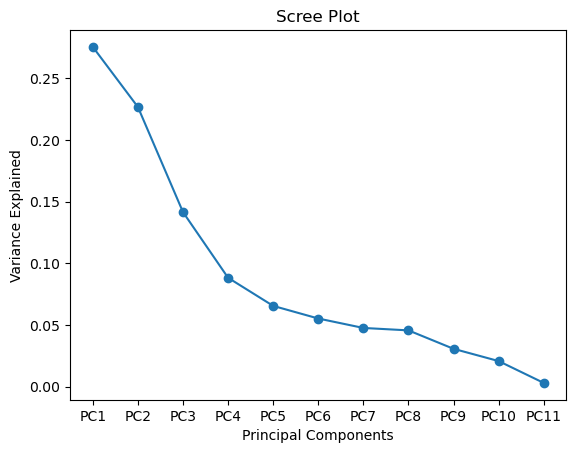

In [49]:
# Applying PCA implementation wine dataset
wine_projected_data, wine_explained_variance = pca_algorithm(dataset=wine_features, k=11)

# Creating scree plots showing explained variance by each principal component
x_axis = range(1,12) # for x-axis
plt.plot(x_axis, wine_explained_variance, marker='o')

x_axis_labels = [f'PC{i}' for i in x_axis] # this will create labels like PC1, PC2 and so on

plt.xticks(x_axis,x_axis_labels)

# setting plot title and axis labels
plt.title("Scree Plot")
plt.xlabel("Principal Components")
plt.ylabel("Variance Explained")
plt.show()

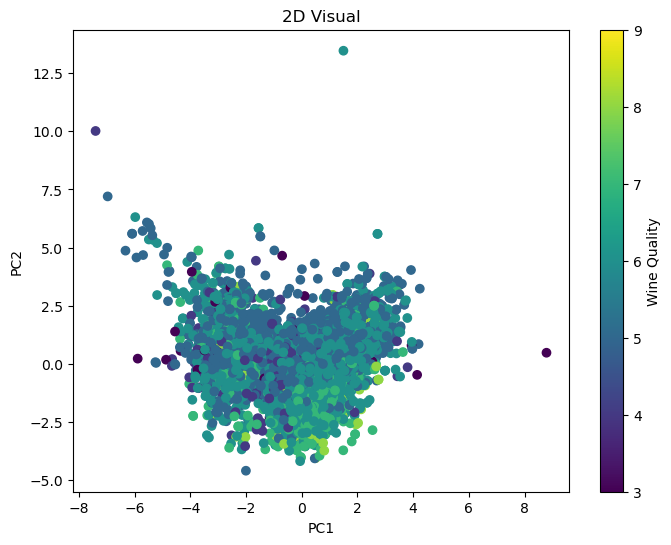

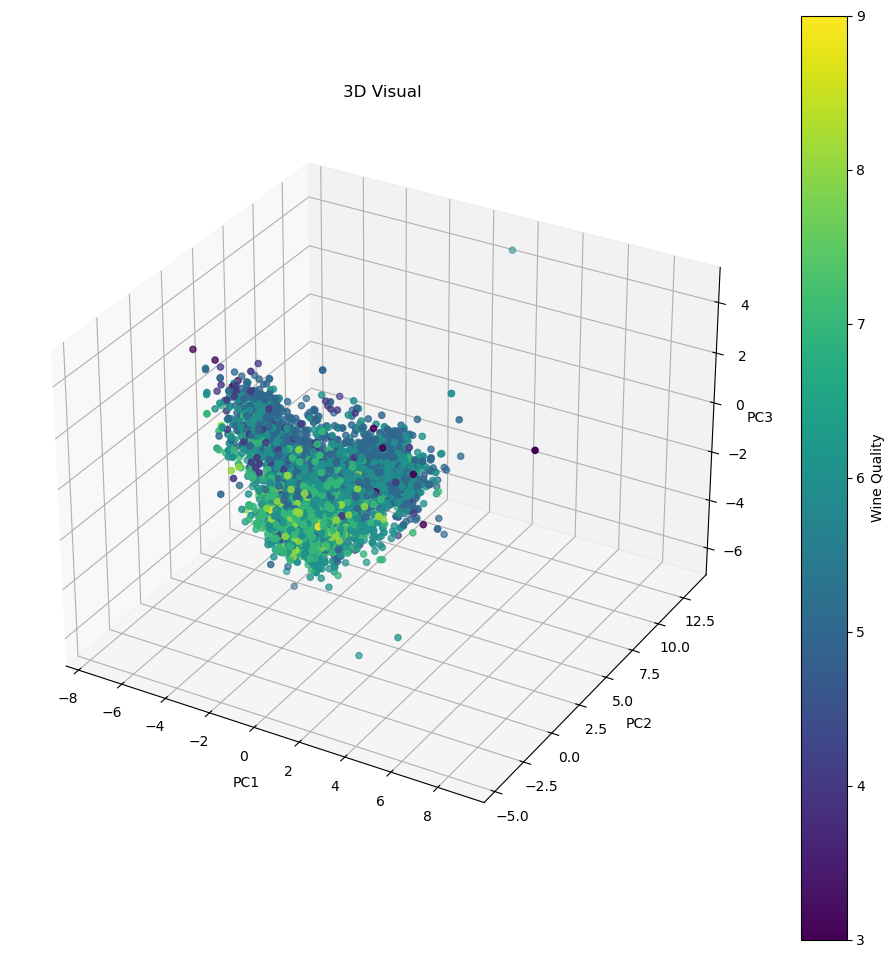

In [ ]:
# Visualizing data in 2D and 3D using the top principal components

# creating 2D visualization (k=2)
# Applying PCA implementation wine dataset
wine_projected_data, wine_explained_variance = pca_algorithm(dataset=wine_features, k=2)

# plotting 2D visual with PC1 on X-axis, PC2 on Y-axis
plt.figure(figsize=(8, 6))
plt.scatter(wine_projected_data[:,0], wine_projected_data[:,1], c= wine_quality_score, cmap='viridis')
plt.colorbar(label='Wine Quality')

# setting plot title and axis labels
plt.title("2D Visual")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.show()

# creating 3D visualization (k=3)
# Applying PCA implementation wine dataset
wine_projected_data, wine_explained_variance = pca_algorithm(dataset=wine_features, k=3)

# plotting 3D visual with PC1 on X-axis, PC2 on Y-axis and PC3 on Z-axis
# setting 3D plot for the visual
fig = plt.figure(figsize=(12,12))
ax = fig.add_subplot(111, projection='3d')
visual = ax.scatter(wine_projected_data[:,0], wine_projected_data[:,1], wine_projected_data[:,2], c= wine_quality_score, cmap='viridis')
fig.colorbar(visual, label='Wine Quality')

# setting plot title and axis labels
ax.set_title("3D Visual")
ax.set_xlabel("PC1", labelpad=5)
ax.set_ylabel("PC2", labelpad=5)
ax.set_zlabel("PC3", labelpad=0)

plt.show()

#### Parameter analysis

Components: 1 | Accuracy: 36.23076923076923%
Components: 2 | Accuracy: 33.92307692307692%
Components: 3 | Accuracy: 39.69230769230769%
Components: 4 | Accuracy: 39.38461538461539%
Components: 5 | Accuracy: 43.230769230769226%
Components: 6 | Accuracy: 45.230769230769226%
Components: 7 | Accuracy: 45.53846153846154%
Components: 8 | Accuracy: 45.0%
Components: 9 | Accuracy: 46.76923076923077%
Components: 10 | Accuracy: 47.69230769230769%
Components: 11 | Accuracy: 47.07692307692308%


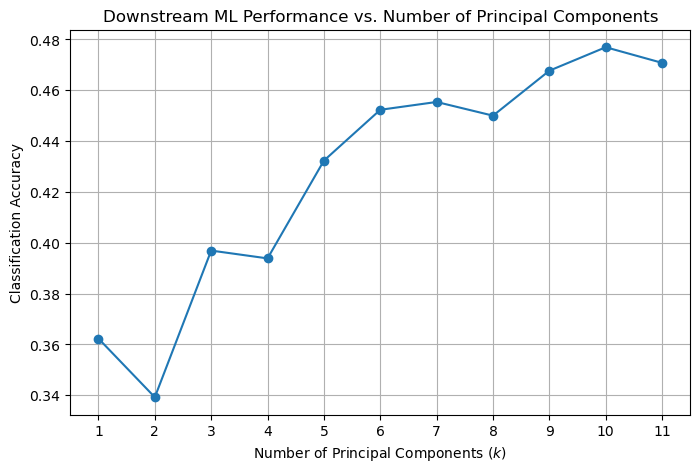

In [107]:
# Q. Performance of a simple downstream ML task
def simple_knn_predict(X_train_proj, y_train, X_test_proj):
    y_pred = []
    for test_point in X_test_proj:
        # Calculating Euclidean distance from this test point to all training points
        distances = np.sqrt(np.sum((X_train_proj - test_point) ** 2, axis=1))

        # Finding the index of the closest training point
        nearest_idx = np.argmin(distances)

        # Assigning the label of the nearest neighbor
        y_pred.append(y_train[nearest_idx])
    return np.array(y_pred)

# custom accuracy scoring function
def accuracy_score_custom(y_true, y_pred):
    return np.mean(y_true == y_pred)

# Setting up the loop
max_components = wine_features.shape[1] 
component_range = range(1, max_components + 1)
accuracies = []

# Splitting the target labels (80% train, 20% test)
split_idx = int(len(wine_quality_score) * 0.8)
y_train = wine_quality_score[:split_idx]
y_test = wine_quality_score[split_idx:]

for k in component_range:
    # Using my existing pca_algorithm to get the projected data for 'k' components
    projected_data, _ = pca_algorithm(dataset=wine_features, k=k)
    
    # Splitting the newly projected data into train and test sets
    X_train_proj = projected_data[:split_idx]
    X_test_proj = projected_data[split_idx:]
    
    # Predicting using the custom downstream ML task
    y_pred = simple_knn_predict(X_train_proj, y_train, X_test_proj)
    
    # Calculating accuracy
    acc = accuracy_score_custom(y_test, y_pred)
    accuracies.append(acc)
    print(f"Components: {k} | Accuracy: {acc * 100}%")

# plotting the output
plt.figure(figsize=(8, 5))
plt.plot(component_range, accuracies, marker='o', linestyle='-')
plt.title('Downstream ML Performance vs. Number of Principal Components')
plt.xlabel('Number of Principal Components ($k$)')
plt.ylabel('Classification Accuracy')
plt.grid(True)
plt.xticks(component_range)
plt.show()

##### Q. Analysis of results and insights

- General Upward Trend: As the number of principal components ($k$) increases from 1 to 10, the overall classification accuracy of the 1-NN model climbs from 36.23% to a peak of 47.69%. This demonstrates that the higher-ranked principal components are successfully capturing the most critical variance and underlying patterns necessary to separate the wine quality classes.
  
- The Peak and the Noise: The model achieves its absolute highest accuracy (47.69%) using $k=10$ components. When we add the 11th component (meaning we are essentially using the full dimensionality of the dataset), the accuracy actually drops to 47.07%.